# ChatGPT code

In [1]:
import numpy as np
from scipy import stats

old_times = np.array([
    39, 42, 37, 41, 36, 40, 38, 43, 35, 39,
    41, 38, 37, 40, 42, 36, 39, 41, 38, 40
])

new_times = np.array([
    34, 36, 35, 33, 37, 34, 35, 36, 32, 34,
    35, 33, 36, 34, 35, 37, 33, 34, 36, 35
])

t_stat, p_two_sided = stats.ttest_ind(
    new_times,
    old_times,
    equal_var=False
)

p_one_sided = p_two_sided / 2 if t_stat < 0 else 1 - p_two_sided / 2

print(f"Old mean: {old_times.mean():.2f}")
print(f"New mean: {new_times.mean():.2f}")
print(f"t statistic: {t_stat:.4f}")
print(f"One-sided p-value: {p_one_sided:.6f}")

Old mean: 39.10
New mean: 34.70
t statistic: -7.5227
One-sided p-value: 0.000000


In [2]:
mean_difference = old_times.mean() - new_times.mean()

print(f"Average reduction: {mean_difference:.2f} minutes")
print(f"Relative reduction: {mean_difference / old_times.mean():.2%}")


Average reduction: 4.40 minutes
Relative reduction: 11.25%


In [3]:
import numpy as np

states = ["Sunny", "Cloudy", "Rainy"]

P = np.array([
    [0.7, 0.2, 0.1],
    [0.3, 0.5, 0.2],
    [0.2, 0.4, 0.4]
])

initial_distribution = np.array([1.0, 0.0, 0.0])

distribution_after_7_days = initial_distribution @ np.linalg.matrix_power(P, 7)

for state, probability in zip(states, distribution_after_7_days):
    print(f"{state}: {probability:.2%}")

Sunny: 46.98%
Cloudy: 33.94%
Rainy: 19.08%


In [4]:
eigenvalues, eigenvectors = np.linalg.eig(P.T)

index = np.argmin(np.abs(eigenvalues - 1))
steady_state = np.real(eigenvectors[:, index])

steady_state = steady_state / steady_state.sum()

for state, probability in zip(states, steady_state):
    print(f"Long-run {state}: {probability:.2%}")

Long-run Sunny: 46.81%
Long-run Cloudy: 34.04%
Long-run Rainy: 19.15%


In [5]:
arrival_rate = 20
service_rate = 25

utilization = arrival_rate / service_rate
average_queue_length = arrival_rate**2 / (
    service_rate * (service_rate - arrival_rate)
)
average_waiting_time_hours = arrival_rate / (
    service_rate * (service_rate - arrival_rate)
)
average_time_in_system_hours = 1 / (service_rate - arrival_rate)

print(f"Utilization: {utilization:.2%}")
print(f"Average queue length: {average_queue_length:.2f} customers")
print(f"Average waiting time: {average_waiting_time_hours * 60:.2f} minutes")
print(f"Average total time in system: {average_time_in_system_hours * 60:.2f} minutes")

Utilization: 80.00%
Average queue length: 3.20 customers
Average waiting time: 9.60 minutes
Average total time in system: 12.00 minutes


In [6]:
import numpy as np

n_simulations = 1_000_000

x = np.random.uniform(-1, 1, n_simulations)
y = np.random.uniform(-1, 1, n_simulations)

inside_circle = x**2 + y**2 <= 1

pi_estimate = 4 * inside_circle.mean()

print(f"Estimated pi: {pi_estimate:.6f}")

Estimated pi: 3.141604


In [7]:
import numpy as np

n_simulations = 100_000
rng = np.random.default_rng(seed=42)

analysis_days = rng.triangular(left=3, mode=5, right=8, size=n_simulations)
development_days = rng.triangular(left=10, mode=15, right=25, size=n_simulations)
testing_days = rng.triangular(left=4, mode=7, right=12, size=n_simulations)
release_days = rng.triangular(left=2, mode=3, right=5, size=n_simulations)

total_days = (
    analysis_days
    + development_days
    + testing_days
    + release_days
)

deadline = 35
on_time_probability = np.mean(total_days <= deadline)

print(f"Expected duration: {total_days.mean():.2f} days")
print(f"Median duration: {np.median(total_days):.2f} days")
print(f"90th percentile duration: {np.percentile(total_days, 90):.2f} days")
print(f"Probability of finishing within {deadline} days: {on_time_probability:.2%}")

Expected duration: 33.00 days
Median duration: 32.79 days
90th percentile duration: 38.07 days
Probability of finishing within 35 days: 70.62%


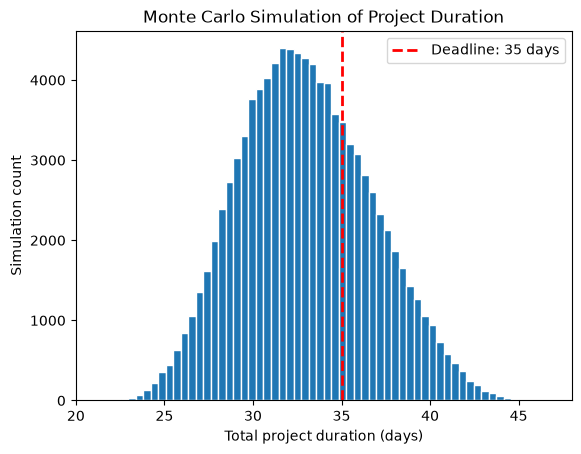

In [8]:
import matplotlib.pyplot as plt

plt.hist(total_days, bins=60, edgecolor="white")
plt.axvline(
    deadline,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Deadline: {deadline} days"
)

plt.xlabel("Total project duration (days)")
plt.ylabel("Simulation count")
plt.title("Monte Carlo Simulation of Project Duration")
plt.legend()
plt.show()

In [11]:
import numpy as np
from scipy.stats import chisquare

observed = np.array([15, 18, 25, 16, 22, 24])
expected = np.full(shape=6, fill_value=20)

chi2_statistic, p_value = chisquare(
    f_obs=observed,
    f_exp=expected
)

print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"p-value: {p_value:.4f}")


Chi-square statistic: 4.5000
p-value: 0.4799


In [12]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: The die may not be fair.")
else:
    print("Fail to reject H0: There is insufficient evidence that the die is unfair.")

Fail to reject H0: There is insufficient evidence that the die is unfair.


In [13]:
import numpy as np
from scipy.stats import chi2_contingency

observed_table = np.array([
    [70, 30],
    [50, 50]
])

chi2_statistic, p_value, degrees_of_freedom, expected_table = chi2_contingency(
    observed_table,
    correction=False
)

print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print("Expected frequencies:")
print(expected_table)

Chi-square statistic: 8.3333
p-value: 0.0039
Degrees of freedom: 1
Expected frequencies:
[[60. 40.]
 [60. 40.]]


In [14]:
import numpy as np

states = ["Silent", "Active", "Churned"]

transition_matrix = np.array([
    [0.60, 0.35, 0.05],
    [0.20, 0.70, 0.10],
    [0.00, 0.00, 1.00]
])

state_distribution = np.array([0.0, 1.0, 0.0])

for day in range(1, 11):
    state_distribution = state_distribution @ transition_matrix

    print(f"Day {day}")
    for state, probability in zip(states, state_distribution):
        print(f"  {state}: {probability:.2%}")

Day 1
  Silent: 20.00%
  Active: 70.00%
  Churned: 10.00%
Day 2
  Silent: 26.00%
  Active: 56.00%
  Churned: 18.00%
Day 3
  Silent: 26.80%
  Active: 48.30%
  Churned: 24.90%
Day 4
  Silent: 25.74%
  Active: 43.19%
  Churned: 31.07%
Day 5
  Silent: 24.08%
  Active: 39.24%
  Churned: 36.68%
Day 6
  Silent: 22.30%
  Active: 35.90%
  Churned: 41.80%
Day 7
  Silent: 20.56%
  Active: 32.93%
  Churned: 46.51%
Day 8
  Silent: 18.92%
  Active: 30.25%
  Churned: 50.83%
Day 9
  Silent: 17.40%
  Active: 27.80%
  Churned: 54.80%
Day 10
  Silent: 16.00%
  Active: 25.55%
  Churned: 58.45%


In [15]:
transition_after_7_days = np.linalg.matrix_power(
    transition_matrix,
    7
)

active_index = 1
churned_index = 2

churn_probability = transition_after_7_days[
    active_index,
    churned_index
]

print(f"Probability of churn within 7 days: {churn_probability:.2%}")


Probability of churn within 7 days: 46.51%


In [16]:
rewards = np.array([0.0, 5.0, 0.0])

expected_daily_revenue = state_distribution @ rewards

print(f"Expected daily revenue per user: {expected_daily_revenue:.2f}")

Expected daily revenue per user: 1.28


In [17]:
initial_distribution = np.array([0.0, 1.0, 0.0])
current_distribution = initial_distribution.copy()

rewards = np.array([0.0, 5.0, 0.0])
total_expected_revenue = 0.0

for day in range(30):
    daily_expected_revenue = current_distribution @ rewards
    total_expected_revenue += daily_expected_revenue

    current_distribution = current_distribution @ transition_matrix

print(f"Expected 30-day cumulative revenue: {total_expected_revenue:.2f}")

Expected 30-day cumulative revenue: 37.06


In [18]:
import numpy as np

states = ["Silent", "Active"]
actions = ["NoAction", "SendCoupon"]

transition_probabilities = {
    "Silent": {
        "NoAction": np.array([0.8, 0.2]),
        "SendCoupon": np.array([0.4, 0.6])
    },
    "Active": {
        "NoAction": np.array([0.2, 0.8]),
        "SendCoupon": np.array([0.1, 0.9])
    }
}

state_rewards = np.array([0.0, 5.0])

action_costs = {
    "NoAction": 0.0,
    "SendCoupon": 2.0
}

discount_factor = 0.9
values = np.zeros(len(states))

for iteration in range(1000):
    new_values = np.zeros(len(states))

    for state_index, state in enumerate(states):
        action_values = []

        for action in actions:
            probabilities = transition_probabilities[state][action]

            expected_immediate_reward = (
                probabilities @ state_rewards
                - action_costs[action]
            )

            expected_future_value = probabilities @ values

            total_action_value = (
                expected_immediate_reward
                + discount_factor * expected_future_value
            )

            action_values.append(total_action_value)

        new_values[state_index] = max(action_values)

    if np.max(np.abs(new_values - values)) < 1e-10:
        break

    values = new_values

print(f"Iterations: {iteration + 1}")
print("Optimal state values:")

for state, value in zip(states, values):
    print(f"  {state}: {value:.4f}")

print("\nOptimal policy:")

for state_index, state in enumerate(states):
    action_values = []

    for action in actions:
        probabilities = transition_probabilities[state][action]

        expected_immediate_reward = (
            probabilities @ state_rewards
            - action_costs[action]
        )

        expected_future_value = probabilities @ values

        total_action_value = (
            expected_immediate_reward
            + discount_factor * expected_future_value
        )

        action_values.append(total_action_value)

    best_action_index = int(np.argmax(action_values))
    best_action = actions[best_action_index]

    print(f"  In state {state}, choose: {best_action}")

Iterations: 231
Optimal state values:
  Silent: 29.7561
  Active: 33.4146

Optimal policy:
  In state Silent, choose: SendCoupon
  In state Active, choose: NoAction
